In [1]:
from DATA.stock_invest_function import *
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

matplotlib.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# ratio_forecast_monthly_result_with_exog = forecast_future_with_sarima(merged_monthly_df, freq='M', forecast_steps=12,
#                                                                       date_col='date', value_col='endog_var',
#                                                                       exog_col='exog_var', use_log=False,
#                                                                       fixed_variable=0)


def forecast_ratio_with_lstm_korea(ratio_df, window_size=60, forecast_days=31):
    # 3. 스케일링
    series = ratio_df[['PSR']].copy()
    scaler = MinMaxScaler()
    scaled_series = scaler.fit_transform(series)

    # 4. 시퀀스 데이터 준비
    def create_sequences(data, window_size=60):
        X, y = [], []
        for i in range(window_size, len(data)):
            X.append(data[i - window_size:i])
            y.append(data[i])
        return np.array(X), np.array(y)

    X_train, y_train = create_sequences(scaled_series, window_size)

    # 5. LSTM 모델 학습
    model = Sequential([
        LSTM(50, activation='relu', input_shape=(window_size, 1)),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0)

    # 6. 미래 예측
    future = list(scaled_series[-window_size:].reshape(-1))
    predictions = []

    for _ in range(forecast_days):
        x_input = np.array(future[-window_size:]).reshape(1, window_size, 1)
        next_pred = model.predict(x_input, verbose=0)
        predictions.append(next_pred[0][0])
        future.append(next_pred[0][0])

    forecasted_psr = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))

    # 7. 미래 날짜 생성
    last_date = df_daily_psr['date'].max()
    forecast_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=forecast_days)

    forecast_df = pd.DataFrame({'date': forecast_dates, 'forecasted_PSR': forecasted_psr.flatten()})

    return forecast_df

# 공통적으로 melt (long format)
def melt_forecast_df(df):
    return df.melt(
        id_vars=['frequency', 'ticker', 'forecast_date'],
        var_name='indicator',
        value_name='value'
    )

In [12]:
# save_path = r"C:\Users\MetaM\PycharmProjects\stock_forecast\DATA"
tic_name = 'A036190'
# 상관관계는 높지 않음
hs_code = '8502'
st_date = '2013-03-01'
end_date = '2025-03-31'
forecast_start_date = '2025-06-01'
forecast_end_date = '2026-06-01'

# 오늘 날짜 구하기 (YYYY-MM-DD)
today_date = pd.to_datetime(datetime.today().date())

# DB 접속 정보 설정
db_info = {
    'user': 'stox7412',         # 예: 'root'
    'password': 'Apt106503!~', # 예: '1234'
    # 'host': '192.168.0.230',
    'host': get_db_host(),         # 예: 'localhost' 또는 IP
    'port': '3307',              # 기본 포트는 보통 3306
    'database': 'investar'        # 예: 'trade_data'
}

✅ 'korea_fs_data' 테이블에서 5584577건의 데이터를 가져왔습니다.
✅ root_hs_code=8502에 해당하는 224개 행을 불러왔습니다.
✅ root_hs_code=8502에 해당하는 224개 행을 불러왔습니다.
🔍 Grid Search 진행 중...
✅ 최적 모형: order=(0, 1, 1), seasonal_order=(1, 1, 0, 4), AIC=1569.67


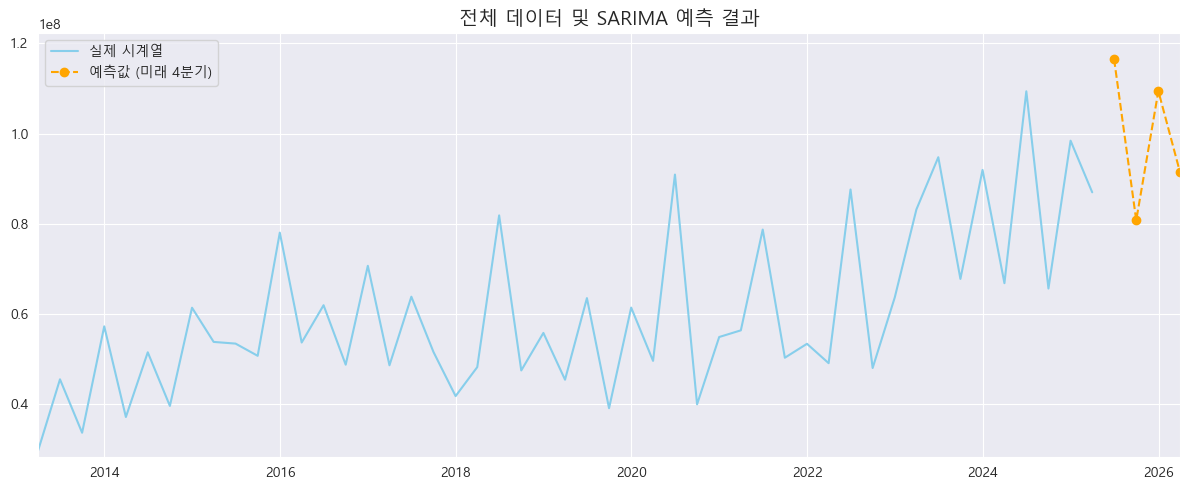


📈 미래 4분기 예측 결과:
2025-06-30    1.164723e+08
2025-09-30    8.076239e+07
2025-12-31    1.094176e+08
2026-03-31    9.143357e+07
Freq: QE-DEC, Name: predicted_mean, dtype: float64

📊 Ljung-Box Test (잔차 자기상관):
     lb_stat  lb_pvalue
4   1.092431   0.895471
8   1.920568   0.983351
12  5.146901   0.952891


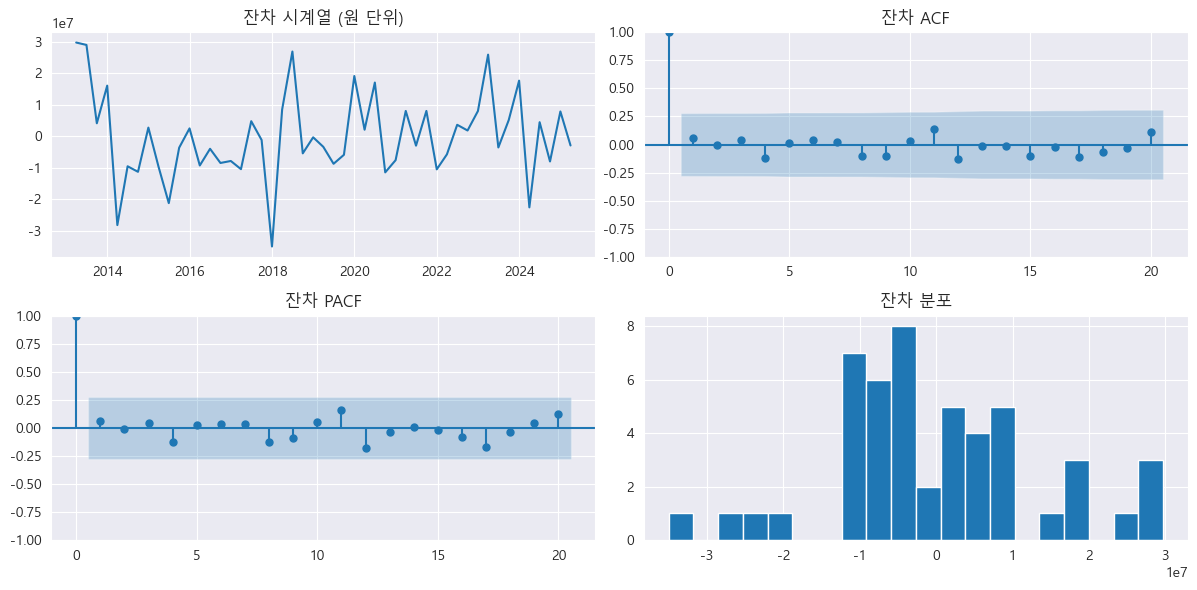

📎 외생변수 'exog_var' 포함
🔍 Grid Search 진행 중...
✅ 최적 모형: order=(0, 1, 1), seasonal_order=(1, 1, 0, 4), AIC=1571.66


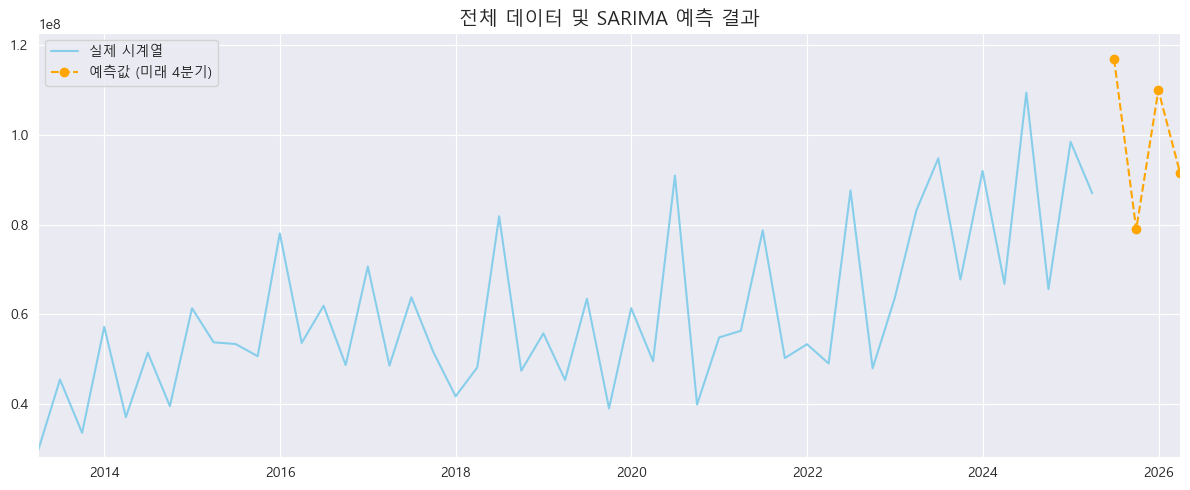


📈 미래 4분기 예측 결과:
2025-06-30    1.167927e+08
2025-09-30    7.893313e+07
2025-12-31    1.099027e+08
2026-03-31    9.156666e+07
Freq: QE-DEC, Name: predicted_mean, dtype: float64

📊 Ljung-Box Test (잔차 자기상관):
     lb_stat  lb_pvalue
4   1.198828   0.878292
8   2.217023   0.973625
12  5.719693   0.929548


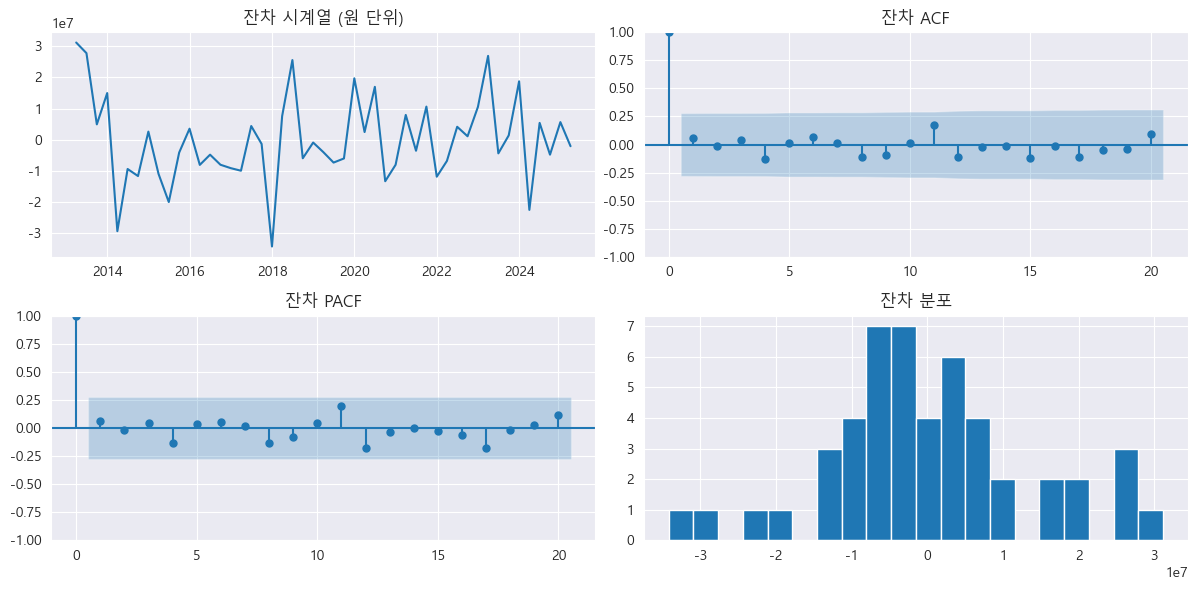

In [13]:
fs_df = fetch_table_data(db_info, "korea_fs_data")
fs_df.rename(columns={'Date': 'date'}, inplace=True)

# 1. indicator 필터링
target_indicator = '매출액(천원)'
filtered_df = fs_df[fs_df['indicator'] == target_indicator].copy()

# 2. 날짜 정제 및 정렬
filtered_df['date'] = pd.to_datetime(filtered_df['date'])
filtered_df.sort_values(by='date', inplace=True)

# 3. value 컬럼이 있는지 확인 및 타입 강제
if 'value' not in filtered_df.columns:
    raise KeyError("'value' 컬럼이 없습니다.")

filtered_df['value'] = pd.to_numeric(filtered_df['value'], errors='coerce')

# 4. 피벗 테이블 생성 (행: date, 열: Symbol, 값: value)
pivot_df = filtered_df.pivot_table(
    index='date',
    columns='symbol',
    values='value',
    aggfunc='first'  # 중복 방지
)

# 5. 전년 동분기 대비 변화율 계산 (4분기 전 대비)
fs_yoy_growth_df = pivot_df.pct_change(periods=4) * 100

endog_df = pivot_df[[tic_name]].reset_index()

temp_df = load_forecast_by_hscode(db_info, hs_code, table_name='korea_monthly_trade_data_forecast')

# 중복 제거
target_export_df = temp_df.drop_duplicates(subset=['date'])

# date를 datetime으로 변환
target_export_df['date'] = pd.to_datetime(target_export_df['date'])

# 분기 추출 및 그룹화
target_export_df['quarter'] = target_export_df['date'].dt.to_period('Q')
quarterly_sum_df = target_export_df.groupby('quarter')['expDlr_forecast_12m'].sum().reset_index()

# datetime 변환 후 추가 계산
quarterly_sum_df['quarter'] = quarterly_sum_df['quarter'].dt.to_timestamp()
quarterly_sum_df['export_qoq_change'] = quarterly_sum_df['expDlr_forecast_12m'].pct_change(periods=1)
quarterly_sum_df['export_yoy_change'] = quarterly_sum_df['expDlr_forecast_12m'].pct_change(periods=4)
quarterly_sum_df['date_month'] = quarterly_sum_df['quarter'] + pd.offsets.QuarterEnd(0)

## 수출 데이터를 불러온다

quarterly_sum_df = get_quarterly_export_forecast(db_info, hs_code)
quarterly_sum_df['date'] = pd.to_datetime(quarterly_sum_df['date_month'])

# 3. date를 인덱스로 설정
quarterly_sum_df.set_index('date', inplace=True)

# ✅ (선택적으로 quarter 컬럼 제거)
quarterly_sum_df.drop(columns='quarter', inplace=True)

quarterly_sum_df = quarterly_sum_df.reset_index()

merged = merge_endog_exog_data(
    endog_df= endog_df,
    exog_df= quarterly_sum_df,
    endog_col=tic_name,
    exog_col='export_yoy_change',
    start_date = st_date,
    end_date = end_date,
)

future_exog_values = quarterly_sum_df[(quarterly_sum_df['date'] >= forecast_start_date) & (quarterly_sum_df['date'] <= forecast_end_date)]['export_yoy_change'].tolist()

revenue_forecasts_without_exog = forecast_future_4q_with_sarima(merged, date_col='date', value_col='endog_var', exog_col=None,  use_log=False, fixed_variable=0)
revenue_forecasts_with_exog = forecast_future_4q_with_sarima(merged, date_col='date', value_col='endog_var', exog_col='exog_var', use_log=False, fixed_variable=0)

🔍 Grid Search 진행 중...
✅ 최적 모형: order=(1, 0, 0), seasonal_order=(0, 1, 1, 4), AIC=-6.88


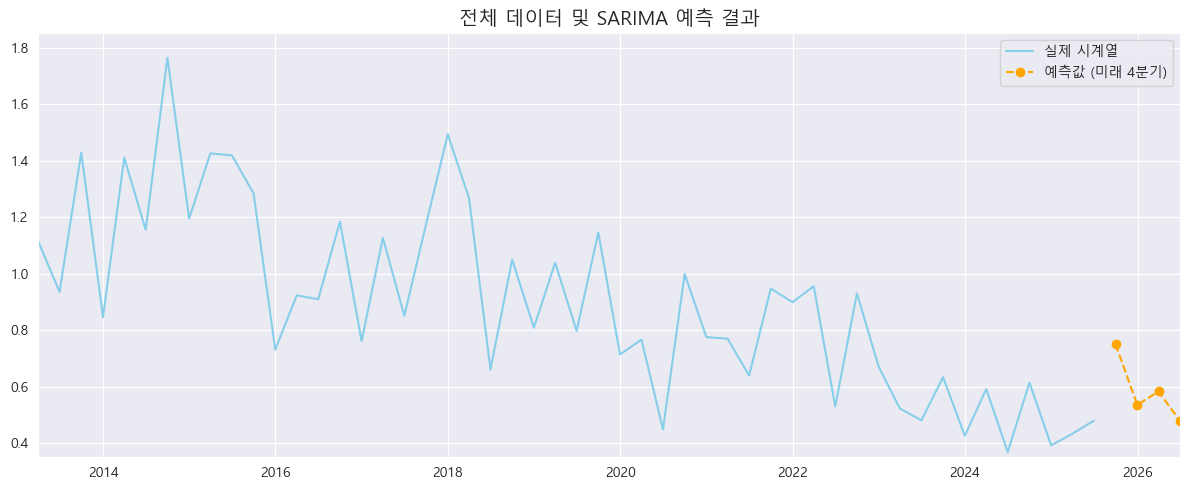


📈 미래 4분기 예측 결과:
2025-09-30    0.750844
2025-12-31    0.536362
2026-03-31    0.583835
2026-06-30    0.479474
Freq: QE-DEC, Name: predicted_mean, dtype: float64

📊 Ljung-Box Test (잔차 자기상관):
      lb_stat  lb_pvalue
4   30.453803   0.000004
8   32.383118   0.000080
12  34.138745   0.000641


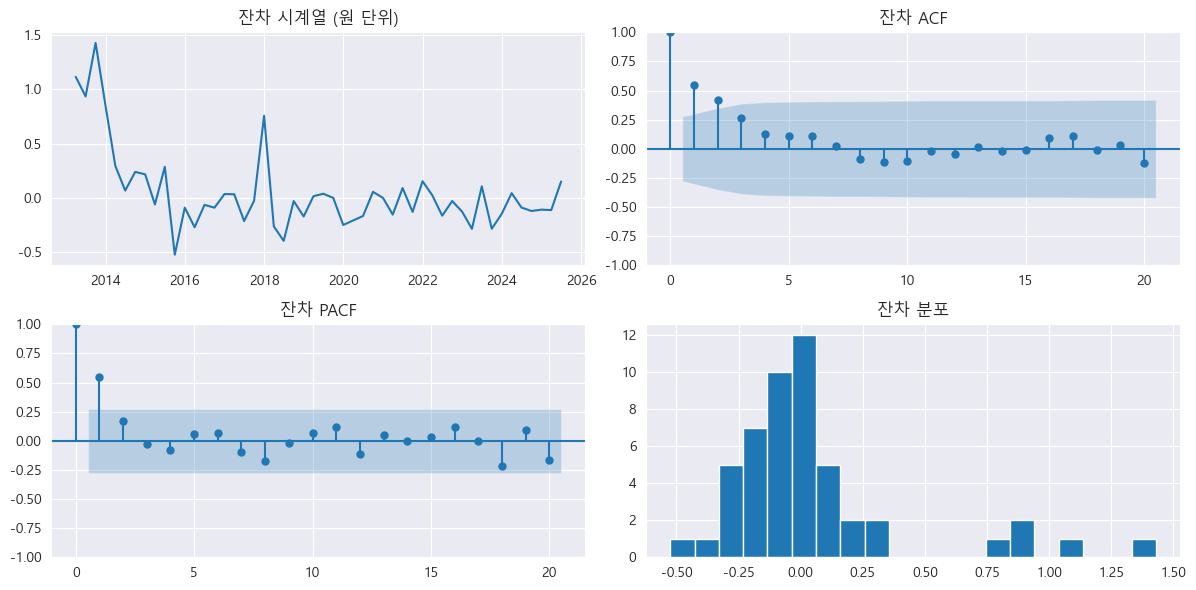

📎 외생변수 'exog_var' 포함
🔍 Grid Search 진행 중...
✅ 최적 모형: order=(1, 0, 0), seasonal_order=(0, 1, 1, 4), AIC=-5.28


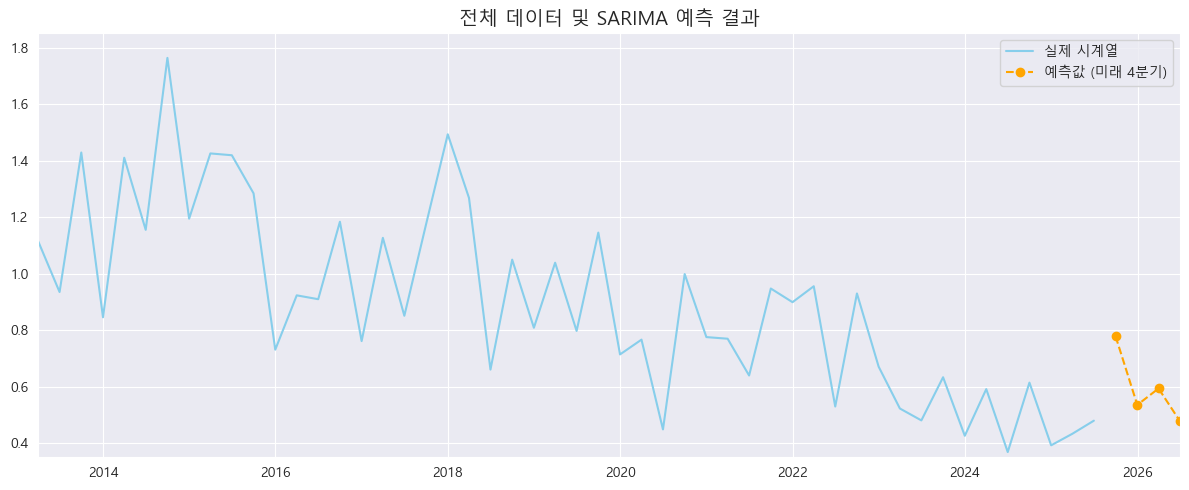


📈 미래 4분기 예측 결과:
2025-09-30    0.779090
2025-12-31    0.536270
2026-03-31    0.594498
2026-06-30    0.478635
Freq: QE-DEC, Name: predicted_mean, dtype: float64

📊 Ljung-Box Test (잔차 자기상관):
      lb_stat  lb_pvalue
4   31.124496   0.000003
8   33.120432   0.000059
12  35.068811   0.000457


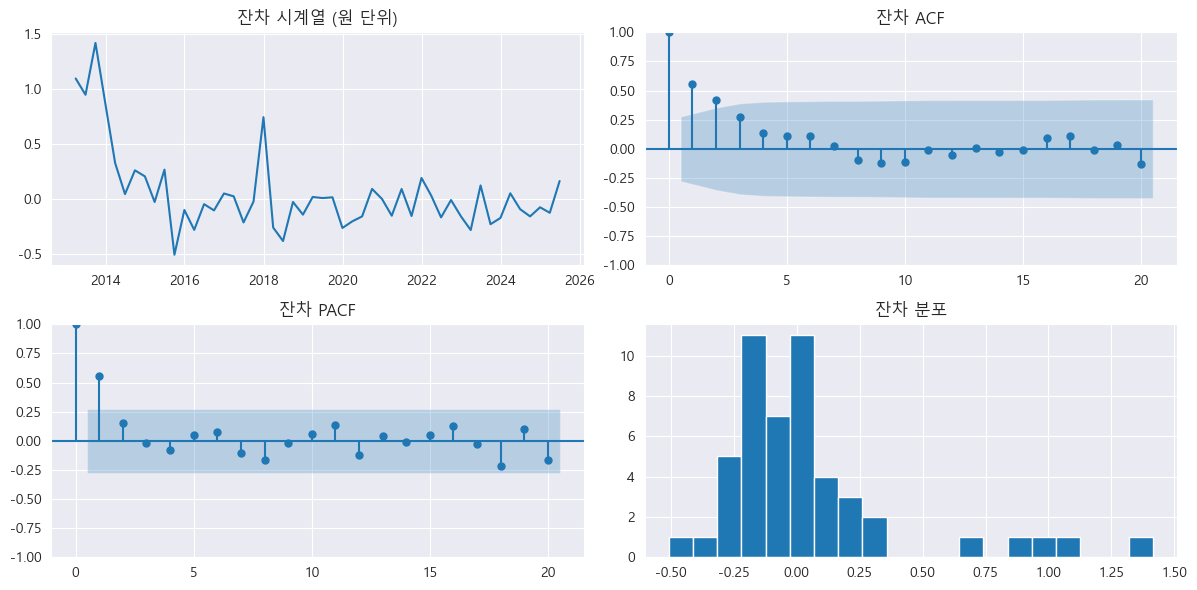

In [14]:
target_indicator = '수정PSR(연율화)(배)'
value_filtered_df = fs_df[(fs_df['indicator'] == target_indicator) & (fs_df['symbol'] == tic_name)].copy()

# 4. 피벗 테이블 생성 (행: date, 열: Symbol, 값: value)
pivot_df = value_filtered_df.pivot_table(
    index='date',
    columns='symbol',
    values='value',
    aggfunc='first'  # 중복 방지
)

value_endog_df = pivot_df[[tic_name]].reset_index()

# 'date' 컬럼이 datetime 타입이 아니라면 변환
value_endog_df['date'] = pd.to_datetime(value_endog_df['date'])
# date 컬럼을 인덱스로 설정 (분기별 재샘플링을 위해)
value_endog_df = value_endog_df.set_index('date')
quarterly_avg_df = value_endog_df.resample('Q').mean()
quarterly_avg_reset = quarterly_avg_df.reset_index()

merged_value_exog = merge_endog_exog_data(
    endog_df = quarterly_avg_reset,
    exog_df = quarterly_sum_df,
    endog_col = tic_name,
    exog_col = 'export_yoy_change',
    start_date = st_date,
    end_date = forecast_end_date
)

ratio_forecast_result_without_exog = forecast_future_4q_with_sarima(merged_value_exog , date_col='date', value_col='endog_var', exog_col=None,  use_log=False, fixed_variable=0)
ratio_forecast_result_with_exog = forecast_future_4q_with_sarima(merged_value_exog , date_col='date', value_col='endog_var', exog_col = 'exog_var',  use_log=False, fixed_variable=0)

In [15]:
# ✅ 해당 ticker 만 추출
df_tic = filtered_df[filtered_df['symbol'] == tic_name].copy()

# ✅ indicator 가 "매출액(천원)" 인 것만 추출
df_sales = df_tic[df_tic['indicator'] == "매출액(천원)"]

# ✅ pivot (date 를 index, indicator 를 칼럼, value 를 값)
df_revenue = df_sales.pivot(
    index='date',
    columns='indicator',
    values='value'
).reset_index()

# ✅ multi-index column name 제거
df_revenue.columns.name = None


# ✅ date 컬럼을 datetime 으로 변환
df_revenue['date'] = pd.to_datetime(df_revenue['date'])

# ✅ 날짜 순으로 정렬
df_revenue = df_revenue.sort_values('date').reset_index(drop=True)

# ✅ rolling 으로 4개 분기 합산
df_revenue['TTM_Revenue'] = df_revenue['매출액(천원)'].rolling(window=4).sum()

# marketcap_df = fetch_table_data(db_info, "ks_listed_company_daily_marketcap")

# ✅ SQLAlchemy 엔진 생성
engine = create_engine(
    f"mysql+pymysql://{db_info['user']}:{db_info['password']}@{db_info['host']}:{db_info['port']}/{db_info['database']}?charset=utf8mb4"
)

# ✅ 조회할 ticker 와 indicator
target_indicator = "시가총액"

# ✅ SQL 쿼리 작성
query = f"""
SELECT date, value
FROM ks_listed_company_daily_marketcap
WHERE ticker = '{tic_name}'
  AND indicator = '{target_indicator}'
ORDER BY date;
"""

# ✅ pandas DataFrame 으로 로드
df_market = pd.read_sql(query, engine)

df_market['date'] = pd.to_datetime(df_market['date'])
df_revenue['date'] = pd.to_datetime(df_revenue['date'])

df_daily_psr = pd.merge(df_market, df_revenue[['date', 'TTM_Revenue']], on='date', how='left').ffill()

df_daily_psr['PSR'] = df_daily_psr['value']/(df_daily_psr['TTM_Revenue']*1000)
df_daily_psr = df_daily_psr[df_daily_psr['PSR'].notna()]

In [16]:
# 1. df_daily_psr 를 월별 마지막 데이터로 축소
df_monthly_psr = df_daily_psr.copy()
df_monthly_psr['date'] = pd.to_datetime(df_monthly_psr['date'])
df_monthly_psr = df_monthly_psr.set_index('date').resample('M').last().reset_index()

# 2. target_export_df 의 date 도 datetime 으로 변환
target_export_df['date'] = pd.to_datetime(target_export_df['date'])

# 3. 두 데이터프레임을 date 기준으로 left join
merged_monthly_df = pd.merge(
    df_monthly_psr[['date', 'PSR']],
    target_export_df[['date', 'final_expDlr_yoy']],
    on='date',
    how='left'
)

# 4. 컬럼명 변경
merged_monthly_df = merged_monthly_df.rename(columns={
    'date': 'date',
    'PSR': 'endog_var',
    'final_expDlr_yoy': 'exog_var'
})

# 5. 결과 확인
print(merged_monthly_df.head())


        date  endog_var  exog_var
0 2020-03-31   0.669906 -0.179595
1 2020-04-30   0.797708  0.091916
2 2020-05-31   0.778046 -0.492433
3 2020-06-30   0.638592  1.130190
4 2020-07-31   0.616185  2.225070


In [17]:
# forecast_future_4q_with_sarima(merged_value_exog , date_col='date', value_col='endog_var', exog_col=None,  use_log=False, fixed_variable=0)
ratio_forecast_monthly_result_without_exog = forecast_future_with_sarima(merged_monthly_df, freq='M', forecast_steps=12, date_col='date', value_col='endog_var', exog_col=None,  use_log=False, fixed_variable=0)

ratio_forecast_monthly_result_with_exog = forecast_future_with_sarima(merged_monthly_df, freq='M', forecast_steps=12, date_col='date', value_col='endog_var', exog_col='exog_var',  use_log=False, fixed_variable=0)

🔍 주기 설정: seasonal_period = 12
🔍 Grid Search 진행 중...
✅ 최적 모형: order=(0, 1, 0), seasonal_order=(1, 0, 1, 12), AIC=-224.45
🔍 주기 설정: seasonal_period = 12
📎 외생변수 'exog_var' 포함
🔍 Grid Search 진행 중...
✅ 최적 모형: order=(0, 1, 0), seasonal_order=(1, 0, 1, 12), AIC=-223.57


In [18]:
ratio_forecast_monthly_result_with_exog

,forecast
2025-09-30,0.559977
2025-10-31,0.561946
2025-11-30,0.565679
2025-12-31,0.561240
2026-01-31,0.555529
2026-02-28,0.562801
2026-03-31,0.579843
2026-04-30,0.588237
2026-05-31,0.568240
2026-06-30,0.535630


In [19]:
# 전제: df_market (일일 시가총액), df_revenue (분기별 TTM 매출)
df_sales = df_sales.sort_values('date')
df_market = df_market.sort_values('date')

lstm_forecast = forecast_ratio_with_lstm_korea(df_daily_psr)

# Prophet 포맷에 맞게 데이터 정리 (컬럼: ds, y)
df_prophet = df_daily_psr.copy()
df_prophet = df_prophet.rename(columns={'date': 'ds', 'PSR': 'y'})
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])

# Prophet 모델 선언 및 학습
model = Prophet(daily_seasonality=True, yearly_seasonality=True)
model.fit(df_prophet)

# 향후 예측 날짜 생성 (예: 90일)
future = model.make_future_dataframe(periods=90)
prophet_forecast = model.predict(future)
#
# # 시각화
# fig1 = model.plot(prophet_forecast)
# plt.title("PSR Forecast using Prophet")
# plt.xlabel("Date")
# plt.ylabel("PSR")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

23:02:46 - cmdstanpy - INFO - Chain [1] start processing
23:02:47 - cmdstanpy - INFO - Chain [1] done processing


In [20]:
revenue_forecasts_with_exog =  revenue_forecasts_with_exog.rename('revenue_with_exog')
revenue_forecasts_without_exog = revenue_forecasts_without_exog.rename('revenue_without_exog')

# revenue_with_exog 값 합산
total_revenue_with_exog = revenue_forecasts_with_exog.sum()
total_revenue_without_exog = revenue_forecasts_without_exog.sum()

# 방법 1: 장기 valuation
value_forecast_with_exog = ratio_forecast_result_with_exog.rename('PSR_quarter_with_exog')
value_forecast_without_exog = ratio_forecast_result_without_exog.rename('PSR_quarter_without_exog')

# 방법 2: 중기 valuation
# 방법 2: 중기 valuation
value_forecast_monthly_with_exog = ratio_forecast_monthly_result_with_exog.rename(
    columns={'forecast': 'PSR_monthly_with_exog'}
)
value_forecast_monthly_without_exog = ratio_forecast_monthly_result_without_exog.rename(
    columns={'forecast': 'PSR_monthly_without_exog'}
)


# 방법 3: 단기 valuation
lstm_forecast = lstm_forecast.rename({'forecasted_PSR': 'PSR_daily_lstm'}, axis=1)
prophet_forecast_resize = prophet_forecast[['ds', 'trend']].rename(columns={'ds': 'date', 'trend': 'PSR_daily_prophet'})

# concat 시 모든 forecast 포함
longterm_value_forecasts = pd.concat(
    [value_forecast_with_exog, value_forecast_without_exog, revenue_forecasts_with_exog, revenue_forecasts_without_exog],
    axis=1
)

longterm_value_forecasts['revenue_with_exog_sum'] = longterm_value_forecasts['revenue_with_exog'].sum()
longterm_value_forecasts['revenue_without_exog_sum'] = longterm_value_forecasts['revenue_without_exog'].sum()
longterm_value_forecasts['value_with_exog'] = longterm_value_forecasts['PSR_quarter_with_exog'] * longterm_value_forecasts['revenue_with_exog_sum']
longterm_value_forecasts['value_without_exog'] = longterm_value_forecasts['PSR_quarter_without_exog'] * longterm_value_forecasts['revenue_without_exog_sum']

# concat 시 모든 forecast 포함
midterm_value_forecasts = pd.concat(
    [value_forecast_monthly_with_exog, value_forecast_monthly_without_exog],
    axis=1
)

midterm_value_forecasts['revenue_with_exog'] = total_revenue_with_exog
midterm_value_forecasts['revenue_without_exog'] = total_revenue_without_exog
midterm_value_forecasts['value_with_exog'] = midterm_value_forecasts['PSR_monthly_with_exog'] * midterm_value_forecasts['revenue_with_exog']
midterm_value_forecasts['value_without_exog'] = midterm_value_forecasts['PSR_monthly_without_exog'] * midterm_value_forecasts['revenue_without_exog']


lstm_forecast_indexed = lstm_forecast.set_index('date')
prophet_forecast_resize_indexed = prophet_forecast_resize.set_index('date')

# concat 시 모든 forecast 포함
shortterm_value_forecasts = pd.concat(
    [lstm_forecast_indexed , prophet_forecast_resize_indexed],
    axis=1, join = 'inner'
)

# shortterm_value_forecasts에 동일 값으로 컬럼 추가
shortterm_value_forecasts['revenue_with_exog'] = total_revenue_with_exog
shortterm_value_forecasts['revenue_without_exog'] = total_revenue_without_exog
# LSTM 기준 가치 계산
shortterm_value_forecasts['lstm_value_with_exog'] = shortterm_value_forecasts['PSR_daily_lstm'] * shortterm_value_forecasts['revenue_with_exog']
shortterm_value_forecasts['lstm_value_without_exog'] = shortterm_value_forecasts['PSR_daily_lstm'] * shortterm_value_forecasts['revenue_without_exog']
# Prophet 기준 가치 계산
shortterm_value_forecasts['prophet_value_with_exog'] = shortterm_value_forecasts['PSR_daily_prophet'] * shortterm_value_forecasts['revenue_with_exog']
shortterm_value_forecasts['prophet_value_without_exog'] = shortterm_value_forecasts['PSR_daily_prophet'] * shortterm_value_forecasts['revenue_without_exog']

longterm_value_forecasts['frequency'] = 'Q'
midterm_value_forecasts['frequency'] = 'M'
shortterm_value_forecasts['frequency'] = 'D'

longterm_value_forecasts['ticker'] = tic_name
midterm_value_forecasts['ticker'] = tic_name
shortterm_value_forecasts['ticker'] = tic_name

longterm_value_forecasts['forecast_date'] = today_date
midterm_value_forecasts['forecast_date'] = today_date
shortterm_value_forecasts['forecast_date'] = today_date

# 공통적으로 melt (long format)
def melt_forecast_df(df):
    return df.melt(
        id_vars=['frequency', 'ticker', 'forecast_date'],
        var_name='indicator',
        value_name='value'
    )

# 각각 melt
longterm_melted = melt_forecast_df(longterm_value_forecasts)
midterm_melted = melt_forecast_df(midterm_value_forecasts)
shortterm_melted = melt_forecast_df(shortterm_value_forecasts)

# 모두 concat
combined_long_format = pd.concat(
    [longterm_melted, midterm_melted, shortterm_melted],
    axis=0,
    ignore_index=True
)

combined_long_format

,frequency,ticker,forecast_date,indicator,value
0,Q,A036190,2025-08-17,PSR_quarter_with_exog,NaN
1,Q,A036190,2025-08-17,PSR_quarter_with_exog,7.790900e-01
2,Q,A036190,2025-08-17,PSR_quarter_with_exog,5.362705e-01
3,Q,A036190,2025-08-17,PSR_quarter_with_exog,5.944979e-01
4,Q,A036190,2025-08-17,PSR_quarter_with_exog,4.786349e-01
...,...,...,...,...,...
355,D,A036190,2025-08-17,prophet_value_without_exog,2.272568e+08
356,D,A036190,2025-08-17,prophet_value_without_exog,2.279634e+08
357,D,A036190,2025-08-17,prophet_value_without_exog,2.286701e+08
358,D,A036190,2025-08-17,prophet_value_without_exog,2.293767e+08


In [21]:
# SQLAlchemy 엔진 생성
engine = create_engine(
    f"mysql+pymysql://{db_info['user']}:{db_info['password']}@{db_info['host']}:{db_info['port']}/{db_info['database']}"
)

# 데이터프레임을 테이블로 저장
combined_long_format.to_sql(
    name='KR_valuation_result_data_V1',
    con=engine,
    if_exists='replace',    # 'replace'는 기존 테이블을 덮어씀, 'append'는 추가
    index=False
)

360

In [22]:
combined_long_format

,frequency,ticker,forecast_date,indicator,value
0,Q,A036190,2025-08-17,PSR_quarter_with_exog,NaN
1,Q,A036190,2025-08-17,PSR_quarter_with_exog,7.790900e-01
2,Q,A036190,2025-08-17,PSR_quarter_with_exog,5.362705e-01
3,Q,A036190,2025-08-17,PSR_quarter_with_exog,5.944979e-01
4,Q,A036190,2025-08-17,PSR_quarter_with_exog,4.786349e-01
...,...,...,...,...,...
355,D,A036190,2025-08-17,prophet_value_without_exog,2.272568e+08
356,D,A036190,2025-08-17,prophet_value_without_exog,2.279634e+08
357,D,A036190,2025-08-17,prophet_value_without_exog,2.286701e+08
358,D,A036190,2025-08-17,prophet_value_without_exog,2.293767e+08
